# Análisis RETC/SINADER — Destinatario Final y Generación Industrial (RCD, RM)
**Regemac S.A. · Informe 1 · ICS3913/ICS3013**

Este cuaderno reemplaza al notebook exploratorio anterior. Los cambios principales:

- Lee las bases **ya estandarizadas** (mismo esquema de columnas y mismo formato de archivo en todos los años), no las bases crudas del RETC con separadores, codificaciones y nombres de columna distintos año a año.
- Incorpora **Generación Industrial (2014-2024)**, además de Destinatario Final (2021-2024), lo que permite mirar el mercado desde el lado del generador (quién declara haber enviado el residuo) y no solo desde el destinatario.
- La metodología de la sección 3 se validó contra la auditoría de Pedro (`Anexo_REGEMAC_revision_final.pdf`, `Resumen_competencia_REGEMAC_revision_final.pdf`): los totales anuales calculados aquí coinciden con los de su Enfoque A (diferencias menores a 0,1%).
- **Ojo:** este cuaderno *no* incluye la estimación de volumen a partir de los reportes de envío internos de Regemac ni el mapa geográfico de comunas — esas secciones dependían del archivo de envíos que se usó en el notebook anterior y no está disponible en este momento. Si quieres esa parte de vuelta, vuelve a subir ese archivo y se agrega.


## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

GITHUB_BASE = "https://raw.githubusercontent.com/fernando25132/Evalpro/refs/heads/main"

# Nombres de archivo esperados en el repo (subcarpetas nuevas, separadas de las bases crudas que ya estaban en la raíz)
DF_FILES = [
    "data/Destinatario_Final/df-sinader-2021-estandarizado.csv",
    "data/Destinatario_Final/df-sinader-2022-estandarizado.csv",
    "data/Destinatario_Final/df-sinader-2023-estandarizado.csv",
    "data/Destinatario_Final/df-sinader-2024-estandarizado_Parte1.csv",
    "data/Destinatario_Final/df-sinader-2024-estandarizado_Parte2.csv",
]

GI_FILES = [
    "data/Generacion_Industrial/gi-sinader-2014-estandarizado.csv",
    "data/Generacion_Industrial/gi-sinader-2015-estandarizado.csv",
    "data/Generacion_Industrial/gi-sinader-2016-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2016-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2017-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2017-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2017-estandarizado_Parte3.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte3.csv",
    "data/Generacion_Industrial/gi-sinader-2018-estandarizado_Parte4.csv",
    "data/Generacion_Industrial/gi-sinader-2019-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2019-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2020-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2020-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2021-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2021-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2022-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2022-estandarizado_Parte2.csv",
    "data/Generacion_Industrial/gi-sinader-2023-estandarizado_Parte1.csv",
    "data/Generacion_Industrial/gi-sinader-2023-estandarizado_Parte2.csv",
] + [f"data/Generacion_Industrial/gi-sinader-2024-estandarizado_Parte{i}.csv" for i in range(1, 13)]

def cargar_estandarizado(rutas_relativas, base=GITHUB_BASE):
    """Lee y concatena archivos ya estandarizados (mismo separador/encoding en todos: coma, utf-8-sig)."""
    partes = [pd.read_csv(f"{base}/{r}", encoding='utf-8-sig', low_memory=False) for r in rutas_relativas]
    return pd.concat(partes, ignore_index=True)

df_all = cargar_estandarizado(DF_FILES)
gi_all = cargar_estandarizado(GI_FILES)

print(f"Destinatario Final: {len(df_all):,} filas, años {sorted(df_all['anio'].unique())}")
print(f"Generación Industrial: {len(gi_all):,} filas, años {sorted(gi_all['anio'].unique())}")


Destinatario Final: 49,555 filas, años [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Generación Industrial: 609,409 filas, años [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Filtro RM + RCD (LER capítulo 17)

Algunos años (DF 2023; GI 2022-2023) traen la columna numérica `ler_capitulo_num` vacía — el número solo quedó en el texto de `ler_capitulo` (ej. `"17 | Residuos de la construcción y demolición"`). El filtro de abajo usa el número cuando existe y si no, lo extrae del texto, para no perder esos años silenciosamente.

In [2]:
def cap17_mask(df):
    num = pd.to_numeric(df['ler_capitulo_num'], errors='coerce')
    txt_num = pd.to_numeric(df['ler_capitulo'].astype(str).str.extract(r'^(\d+)')[0], errors='coerce')
    return num.fillna(txt_num) == 17

def filtro_rm_rcd_destinatario(df, solo_entrada=True):
    """RM + RCD desde el lado del DESTINATARIO (región del establecimiento receptor)."""
    m = df['region'].astype(str).str.contains('Metropolitana', na=False) & cap17_mask(df)
    if solo_entrada and 'tipo_movimiento' in df.columns:
        m &= pd.to_numeric(df['tipo_movimiento'], errors='coerce') == 1
    return df[m].copy()

def filtro_rm_rcd_generador(df):
    """RM + RCD desde el lado del GENERADOR, mirando a qué región va el destinatario declarado (trazabilidad)."""
    m = df['trazabilidad_region'].astype(str).str.contains('Metropolitana', na=False) & cap17_mask(df)
    return df[m].copy()

df_rm = filtro_rm_rcd_destinatario(df_all)
gi_rm = filtro_rm_rcd_generador(gi_all)
print(f"DF, RM+RCD (entrada): {len(df_rm):,} filas")
print(f"GI, RM+RCD (por trazabilidad al destinatario): {len(gi_rm):,} filas")


DF, RM+RCD (entrada): 2,622 filas
GI, RM+RCD (por trazabilidad al destinatario): 15,051 filas


## 3. Validación: ¿coincide con la auditoría de Pedro?

La tabla "Enfoque A" del anexo de Pedro (región del establecimiento, LER 17, `tipo_recepcion = 1`, agrupado por RUT) da estos totales:

| Año | Toneladas | Empresas | Variación |
|---|---|---|---|
| 2021 | 211.117,3 | 12 | — |
| 2022 | 431.826,6 | 32 | +104,54% |
| 2023 | 416.657,8 | 44 | -3,51% |
| 2024 | 951.025,7 | 73 | +128,25% |

Si la tabla de abajo da (casi) los mismos números, confirma que el filtro y la base estandarizada están bien construidos.

In [3]:
tabla_anual = (df_rm.groupby('anio')
               .agg(toneladas=('toneladas', 'sum'), empresas=('rut', 'nunique'))
               .reset_index())
tabla_anual['variacion_%'] = tabla_anual['toneladas'].pct_change() * 100
tabla_anual['toneladas'] = tabla_anual['toneladas'].round(1)
tabla_anual['variacion_%'] = tabla_anual['variacion_%'].round(2)
tabla_anual


,anio,toneladas,empresas,variacion_%
0,2021,211117.3,12,NaN
1,2022,431826.6,32,104.54
2,2023,417055.1,44,-3.42
3,2024,951000.0,73,128.03


## 4. Participación de mercado 2014-2024 y gráfico de líneas (Regemac destacado)

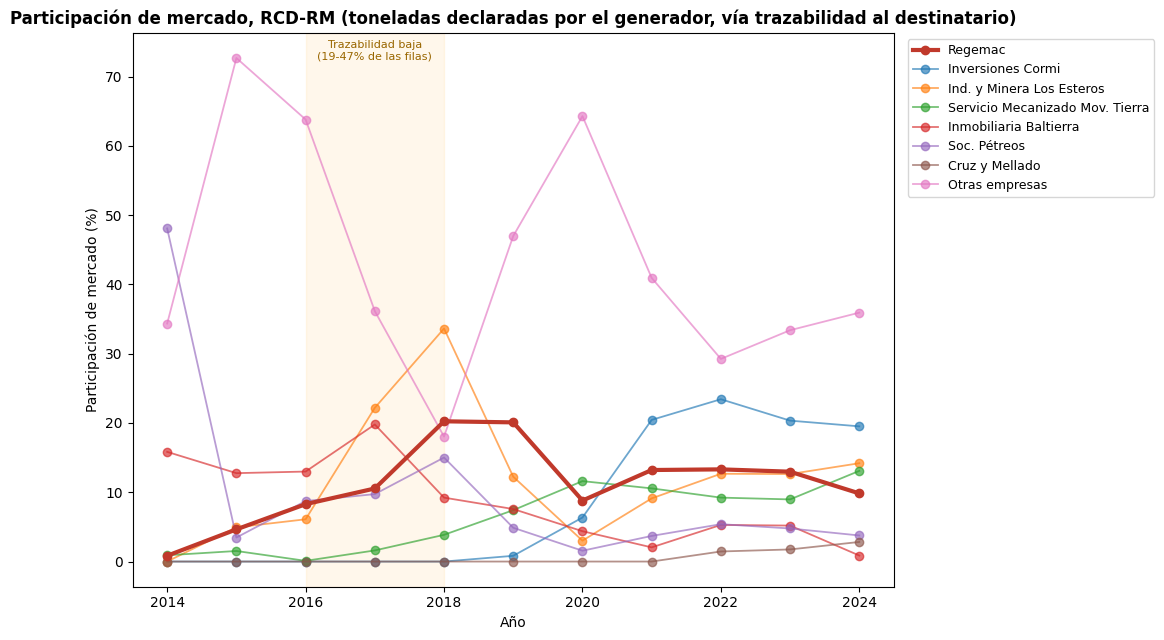

empresa,Regemac,Inversiones Cormi,Ind. y Minera Los Esteros,Servicio Mecanizado Mov. Tierra,Inmobiliaria Baltierra,Soc. Pétreos,Cruz y Mellado,Otras empresas
anio,,,,,,,,
2014,0.84,0.00,0.00,0.91,15.83,48.07,0.00,34.35
2015,4.64,0.00,4.94,1.52,12.76,3.47,0.00,72.67
2016,8.28,0.00,6.10,0.10,12.99,8.73,0.00,63.80
2017,10.55,0.00,22.19,1.60,19.78,9.73,0.00,36.14
2018,20.24,0.00,33.63,3.86,9.23,15.01,0.00,18.04
2019,20.09,0.83,12.24,7.41,7.58,4.87,0.00,46.98
2020,8.80,6.35,3.01,11.61,4.38,1.56,0.00,64.29
2021,13.21,20.44,9.12,10.56,2.04,3.70,0.00,40.93
2022,13.30,23.42,12.67,9.23,5.29,5.39,1.45,29.24


In [4]:
MAPA_EMPRESAS = [
    (r'REGENERADORA DE MATERIALES', 'Regemac'),
    (r'INVERSIONES CORMI', 'Inversiones Cormi'),
    (r'(INDUSTRIAL Y )?MINERA LOS ESTEROS', 'Ind. y Minera Los Esteros'),
    (r'SERVICIO MECANIZADO', 'Servicio Mecanizado Mov. Tierra'),
    (r'BALTIERRA', 'Inmobiliaria Baltierra'),
    (r'SOC(IEDAD)? P[EÉ]TREOS', 'Soc. Pétreos'),
    (r'CRUZ Y MELLADO', 'Cruz y Mellado'),
]

def nombre_normalizado(razon_social):
    rs = str(razon_social).upper()
    for patron, nombre in MAPA_EMPRESAS:
        if re.search(patron, rs):
            return nombre
    return 'Otras empresas'

def nombre_corto_empresa(razon_social, max_len=38):
    """Para etiquetas de gráfico: nombre en Title Case, truncado si es muy largo."""
    n = str(razon_social).title()
    reemplazos = {' S A': ' S.A.', ' Sa': ' S.A.', ' Spa': ' SpA', ' Ltda': ' Ltda.', ' Limitada': ' Ltda.'}
    for k, v in reemplazos.items():
        if n.endswith(k):
            n = n[: -len(k)] + v
    return n if len(n) <= max_len else n[: max_len - 3] + "..."

gi_rm = gi_rm.copy()
gi_rm['empresa'] = gi_rm['trazabilidad_razon_social'].apply(nombre_normalizado)

toneladas_anio_empresa = gi_rm.groupby(['anio', 'empresa'])['toneladas'].sum()
toneladas_anio_total = toneladas_anio_empresa.groupby(level='anio').transform('sum')
participacion = (toneladas_anio_empresa / toneladas_anio_total).reset_index(name='participacion')

orden_empresas = ['Regemac', 'Inversiones Cormi', 'Ind. y Minera Los Esteros',
                   'Servicio Mecanizado Mov. Tierra', 'Inmobiliaria Baltierra',
                   'Soc. Pétreos', 'Cruz y Mellado', 'Otras empresas']

pivot = participacion.pivot(index='anio', columns='empresa', values='participacion').reindex(columns=orden_empresas).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6.5))
for empresa in orden_empresas:
    es_regemac = empresa == 'Regemac'
    ax.plot(pivot.index, pivot[empresa] * 100,
            marker='o', linewidth=3 if es_regemac else 1.3,
            color='#c0392b' if es_regemac else None,
            alpha=1.0 if es_regemac else 0.65,
            label=empresa, zorder=5 if es_regemac else 2)

ax.set_title('Participación de mercado, RCD-RM (toneladas declaradas por el generador, vía trazabilidad al destinatario)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Participación de mercado (%)')
ax.set_xlabel('Año')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax.axvspan(2016, 2018, alpha=0.08, color='orange')
ax.text(2017, ax.get_ylim()[1]*0.95, 'Trazabilidad baja\n(19-47% de las filas)', ha='center', fontsize=8, color='#996600')
plt.tight_layout()
plt.savefig('participacion_mercado_rcd_rm.png', dpi=150, bbox_inches='tight')
plt.show()

pivot.round(4) * 100


**Nota:** estos números pueden diferir levemente (unos pocos puntos porcentuales) de los que se ven en el documento de análisis anterior del proyecto, porque esa versión aplicó además una corrección manual a un grupo de declaraciones de 2024 mal etiquetadas como región Metropolitana (en realidad Arica). Ese ajuste puntual no está reproducido aquí — si quieres que lo agreguemos, dímelo y lo incorporamos como un paso explícito y documentado en vez de dejarlo implícito.

## 5. Concentración de mercado (HHI ponderado por tonelaje)

IHH por tonelaje recibido (2024, destinatarios RM): 1,466
(Referencia: <1500 no concentrado · 1500-2500 moderadamente concentrado · >2500 altamente concentrado)


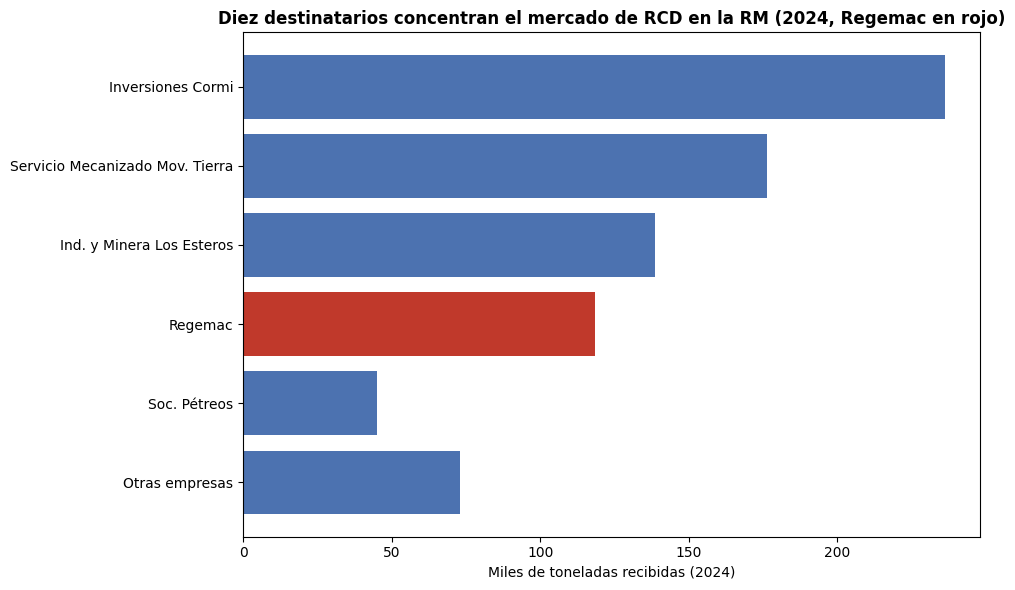

In [5]:
df_rm['empresa'] = df_rm['razon_social'].apply(nombre_normalizado)

tonelaje_actor = df_rm[df_rm['anio'] == df_rm['anio'].max()].groupby('razon_social')['toneladas'].sum()
participaciones_ton = tonelaje_actor / tonelaje_actor.sum()
ihh_tonelaje = ((participaciones_ton * 100) ** 2).sum()

anio_ref = df_rm['anio'].max()
print(f"IHH por tonelaje recibido ({anio_ref}, destinatarios RM): {ihh_tonelaje:,.0f}")
print("(Referencia: <1500 no concentrado · 1500-2500 moderadamente concentrado · >2500 altamente concentrado)")

top10 = tonelaje_actor.sort_values(ascending=False).head(10)
colores = ['#c0392b' if 'REGENERADORA DE MATERIALES' in n else '#4C72B0' for n in top10.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([nombre_normalizado(n) for n in top10.index][::-1], (top10.values / 1000)[::-1], color=colores[::-1])
ax.set_xlabel(f'Miles de toneladas recibidas ({anio_ref})')
ax.set_title(f'Diez destinatarios concentran el mercado de RCD en la RM ({anio_ref}, Regemac en rojo)', fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Composición por material (LER) y tipo de tratamiento

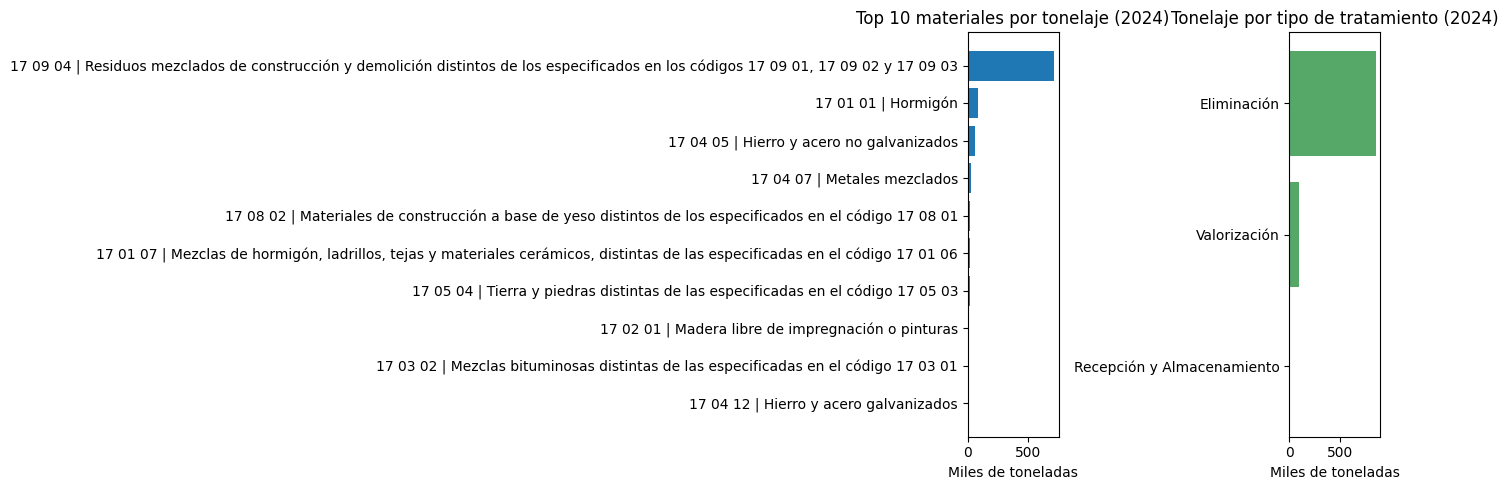

In [6]:
anio_detalle = df_rm['anio'].max()
detalle = df_rm[df_rm['anio'] == anio_detalle]

tonelaje_material = detalle.groupby('ler_nombre')['toneladas'].sum().sort_values(ascending=False).head(10)
tratamiento_n1 = detalle.groupby('tratamiento_n1')['toneladas'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(tonelaje_material.index[::-1], (tonelaje_material.values / 1000)[::-1])
axes[0].set_title(f'Top 10 materiales por tonelaje ({anio_detalle})')
axes[0].set_xlabel('Miles de toneladas')

axes[1].barh(tratamiento_n1.index[::-1], (tratamiento_n1.values / 1000)[::-1], color='#55A868')
axes[1].set_title(f'Tonelaje por tipo de tratamiento ({anio_detalle})')
axes[1].set_xlabel('Miles de toneladas')
plt.tight_layout()
plt.show()


## 7. Cruce generador ↔ destinatario: ¿quiénes son los clientes reales de Regemac?

Generación Industrial declara, por cada envío, quién es el generador Y a qué destinatario fue (`trazabilidad_razon_social`). Filtrando por los envíos cuyo destinatario declarado es Regemac, se obtiene la lista de generadores (constructoras/obras) que efectivamente la usan — una vista que Destinatario Final solo no permite.

In [7]:
envios_a_regemac = gi_all[gi_all['trazabilidad_razon_social'].str.contains('REGENERADORA DE MATERIALES', na=False)]

clientes_regemac = (envios_a_regemac.groupby('razon_social')['toneladas'].sum()
                     .sort_values(ascending=False))

print(f"Generadores distintos que declaran haber enviado a Regemac (todos los años): {clientes_regemac.shape[0]}")
print(f"Toneladas totales declaradas hacia Regemac: {clientes_regemac.sum():,.0f} t")
clientes_regemac.head(15)


Generadores distintos que declaran haber enviado a Regemac (todos los años): 241
Toneladas totales declaradas hacia Regemac: 1,054,637 t


,toneladas
razon_social,
READY MIX HORMIGONES LIMITADA,177833.000
CONSORCIO DE SALUD SANTIAGO ORIENTE S.A. SOCIEDAD CONCESIONARIA,66784.000
SOC INDUSTRIAL ROMERAL S A,61985.387
SINERGIA INMOBILIARIA S.A.,58960.200
INMOBILIARIA ZANARTU S.A.,40618.980
EMPRESA DE TRANSPORTE DE PASAJEROS METRO S A,32718.756
CIA INDUSTRIAL EL VOLCAN S A,30106.100
FIBROCEMENTOS VOLCAN LIMITADA,24451.910
INMOBILIARIA LAMPA ORIENTE S.A.,21083.000


## 8. Nota metodológica: granularidad mensual (`mes`)

No es un simple salto 2023→2024. En el subconjunto RM+RCD:

In [8]:
def resumen_mes(df, col_anio='anio'):
    filas = []
    for anio, sub in df.groupby(col_anio):
        mes_num = pd.to_numeric(sub['mes'], errors='coerce').fillna(0)
        tiene_mes = mes_num > 0
        tons_total = sub['toneladas'].sum()
        tons_mes = sub.loc[tiene_mes, 'toneladas'].sum()
        filas.append({
            'anio': anio, 'filas': len(sub),
            '%_filas_con_mes_real': round(100 * tiene_mes.mean(), 1),
            '%_toneladas_con_mes_real': round(100 * tons_mes / tons_total, 1) if tons_total else 0,
        })
    return pd.DataFrame(filas)

resumen_mes(gi_all[cap17_mask(gi_all) & gi_all['region'].astype(str).str.contains('Metropolitana', na=False)])


,anio,filas,%_filas_con_mes_real,%_toneladas_con_mes_real
0,2014,143,0.0,0.0
1,2015,357,0.0,0.0
2,2016,1469,63.4,16.3
3,2017,2281,55.5,8.3
4,2018,3849,83.7,35.3
5,2019,1655,0.0,0.0
6,2020,929,0.0,0.0
7,2021,1319,0.0,0.0
8,2022,1253,0.0,0.0
9,2023,1573,0.0,0.0


## 9. Flujo de tratamiento de RCD (diagrama de Sankey)

Primario → secundario → terciario del tratamiento declarado. Se construye dos veces con el mismo código: una desde **DF** (destinatario declara su propio tratamiento) y otra desde **GI** (el generador declara a qué tratamiento fue el residuo, según lo que le informó el destinatario) — son fuentes independientes, así que si el reparto general se parece, es una señal cruzada de consistencia.

Categorías de nivel terciario con menos de 12 declaraciones se agrupan en "Otros procesos" para que el diagrama siga siendo legible.

In [9]:
import plotly.graph_objects as go

def sankey_tratamiento(df, titulo, umbral_min_casos=12):
    flujo = df[['tratamiento_n1', 'tratamiento_n2', 'tratamiento_n3']].dropna().copy()

    frecuencia_n3 = flujo['tratamiento_n3'].value_counts()
    n3_frecuentes = set(frecuencia_n3[frecuencia_n3 >= umbral_min_casos].index)
    flujo['n3_agrupado'] = flujo['tratamiento_n3'].apply(
        lambda x: x if x in n3_frecuentes else f'Otros procesos (< {umbral_min_casos} casos c/u)')

    n1_vals = sorted(flujo['tratamiento_n1'].unique().tolist())
    n2_vals = sorted(flujo['tratamiento_n2'].unique().tolist())
    n3_vals = flujo['n3_agrupado'].value_counts().index.tolist()

    nodos = [f"L1·{x}" for x in n1_vals] + [f"L2·{x}" for x in n2_vals] + [f"L3·{x}" for x in n3_vals]
    indice_nodo = {label: i for i, label in enumerate(nodos)}
    etiquetas = n1_vals + n2_vals + n3_vals

    color_n1, color_n2, color_n3 = '#2c3e50', '#2980b9', '#16a085'
    colores_nodo = [color_n1] * len(n1_vals) + [color_n2] * len(n2_vals) + [color_n3] * len(n3_vals)
    pos_x = [0.01] * len(n1_vals) + [0.5] * len(n2_vals) + [0.99] * len(n3_vals)

    enlaces_12 = flujo.groupby(['tratamiento_n1', 'tratamiento_n2']).size().reset_index(name='value')
    enlaces_23 = flujo.groupby(['tratamiento_n2', 'n3_agrupado']).size().reset_index(name='value')

    paleta_n1 = {'Valorización': 'rgba(41,128,185,0.45)', 'Eliminación': 'rgba(192,57,43,0.4)',
                 'Recepción y Almacenamiento': 'rgba(127,140,141,0.4)'}
    sources, targets, values, colores_enlace = [], [], [], []
    for _, row in enlaces_12.iterrows():
        sources.append(indice_nodo[f"L1·{row['tratamiento_n1']}"])
        targets.append(indice_nodo[f"L2·{row['tratamiento_n2']}"])
        values.append(row['value'])
        colores_enlace.append(paleta_n1.get(row['tratamiento_n1'], 'rgba(150,150,150,0.35)'))
    for _, row in enlaces_23.iterrows():
        sources.append(indice_nodo[f"L2·{row['tratamiento_n2']}"])
        targets.append(indice_nodo[f"L3·{row['n3_agrupado']}"])
        values.append(row['value'])
        colores_enlace.append('rgba(22,160,133,0.35)')

    fig = go.Figure(data=[go.Sankey(
        arrangement='fixed',
        node=dict(pad=14, thickness=16, line=dict(color="white", width=0.5),
                  label=etiquetas, color=colores_nodo, x=pos_x),
        link=dict(source=sources, target=targets, value=values, color=colores_enlace)
    )])
    fig.update_layout(title_text=titulo, font_size=11, height=520)
    return fig

sankey_tratamiento(df_rm[df_rm['anio'] == df_rm['anio'].max()],
                    f"DF · Flujo de tratamiento declarado por destinatarios, RCD-RM {int(df_rm['anio'].max())}").show()
sankey_tratamiento(gi_rm[gi_rm['anio'] == gi_rm['anio'].max()],
                    f"GI · Flujo de tratamiento declarado por generadores, RCD-RM {int(gi_rm['anio'].max())}").show()


## 10. Comparación DF vs. GI: ¿cuentan la misma historia?

Total 2024, RM+RCD:  DF = 951,000 t   |   GI = 1,193,837 t
GI normalmente da un total más alto: cubre más establecimientos generadores declarando destino que los que a su vez se autodeclaran como destinatario en DF.


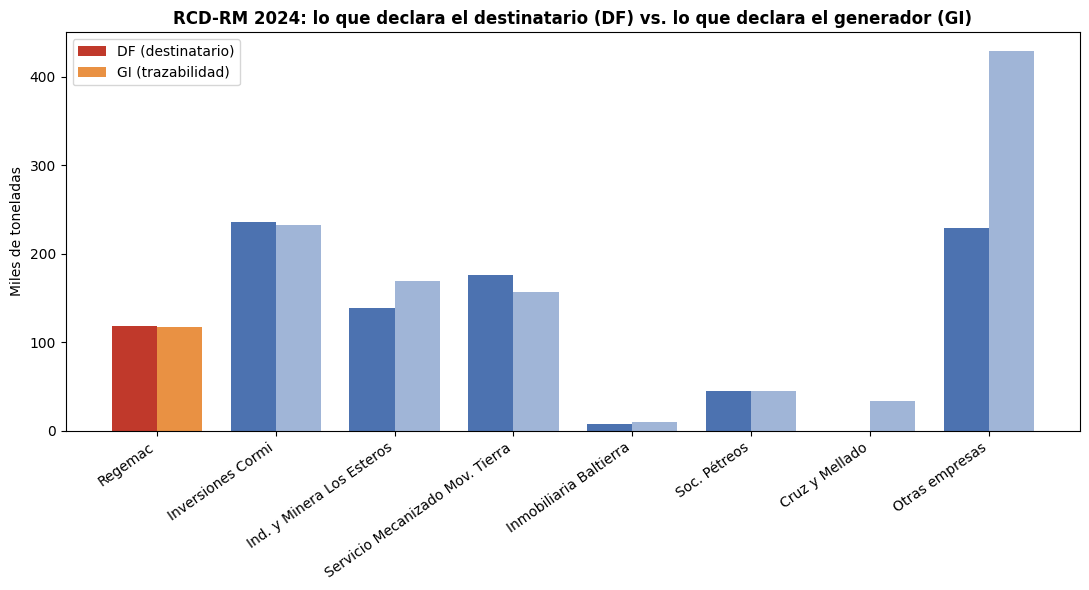

,DF (destinatario),GI (trazabilidad)
empresa,,
Regemac,118457.0,117403.0
Inversiones Cormi,236188.0,232943.0
Ind. y Minera Los Esteros,138615.0,169398.0
Servicio Mecanizado Mov. Tierra,176448.0,156232.0
Inmobiliaria Baltierra,7171.0,10327.0
Soc. Pétreos,44935.0,44935.0
Cruz y Mellado,0.0,33750.0
Otras empresas,229186.0,428849.0


In [10]:
anio_comp = int(min(df_rm['anio'].max(), gi_rm['anio'].max()))

ton_df_comp = df_rm[df_rm['anio'] == anio_comp].groupby('empresa')['toneladas'].sum()
ton_gi_comp = gi_rm[gi_rm['anio'] == anio_comp].assign(
    empresa=gi_rm.loc[gi_rm['anio'] == anio_comp, 'trazabilidad_razon_social'].apply(nombre_normalizado)
).groupby('empresa')['toneladas'].sum()

comparacion = pd.DataFrame({'DF (destinatario)': ton_df_comp, 'GI (trazabilidad)': ton_gi_comp}).reindex(orden_empresas).fillna(0)

print(f"Total {anio_comp}, RM+RCD:  DF = {comparacion['DF (destinatario)'].sum():,.0f} t   |   GI = {comparacion['GI (trazabilidad)'].sum():,.0f} t")
print("GI normalmente da un total más alto: cubre más establecimientos generadores declarando destino que los que a su vez se autodeclaran como destinatario en DF.")

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(comparacion))
ancho = 0.38
colores_df = ['#c0392b' if e == 'Regemac' else '#4C72B0' for e in comparacion.index]
colores_gi = ['#e67e22' if e == 'Regemac' else '#8fa8d1' for e in comparacion.index]
ax.bar(x - ancho/2, comparacion['DF (destinatario)'] / 1000, ancho, label='DF (destinatario)', color=colores_df)
ax.bar(x + ancho/2, comparacion['GI (trazabilidad)'] / 1000, ancho, label='GI (trazabilidad)', color=colores_gi, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comparacion.index, rotation=35, ha='right')
ax.set_ylabel('Miles de toneladas')
ax.set_title(f'RCD-RM {anio_comp}: lo que declara el destinatario (DF) vs. lo que declara el generador (GI)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

comparacion.round(0)


**Lectura:** cuando ambas fuentes coinciden razonablemente para una empresa (Regemac, Cormi, Soc. Pétreos), es una señal cruzada de que el número es confiable. Cuando difieren mucho (revisa "Cruz y Mellado" u "Otras empresas"), puede deberse a que la empresa no se autodeclaró como destinatario en DF ese año, a diferencias de cobertura entre ambos registros, o a que DF exige entrada `tipo_movimiento = 1` mientras GI no filtra por eso — no asumas automáticamente que una de las dos fuentes "está mal".

## 11. Mayores generadores de residuos (mercado completo, 2024)

Hasta ahora todo el cuaderno mira quién *recibe* el RCD. GI también permite ver quién lo *genera* — es decir, qué constructoras/obras están detrás del volumen. Esto es distinto al listado de clientes de Regemac de la sección 7: aquí es el mercado completo, sin filtrar por destinatario.

Generadores distintos en 2024 (RM+RCD): 591


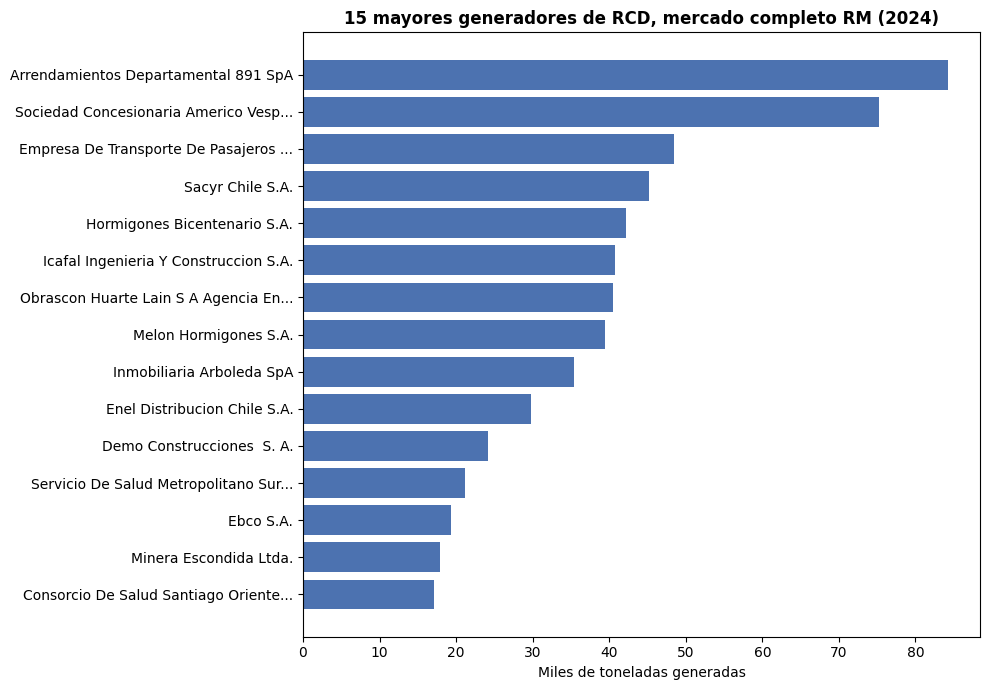

,toneladas
razon_social,
ARRENDAMIENTOS DEPARTAMENTAL 891 SPA,84214.0000
SOCIEDAD CONCESIONARIA AMERICO VESPUCIO ORIENTE II S.A.,75242.2530
EMPRESA DE TRANSPORTE DE PASAJEROS METRO S A,48472.6852
SACYR CHILE S A,45193.5610
HORMIGONES BICENTENARIO S.A.,42180.4600
ICAFAL INGENIERIA Y CONSTRUCCION S A,40765.7400
OBRASCON HUARTE LAIN S A AGENCIA EN CHILE,40540.7320
MELON HORMIGONES S.A.,39471.7400
INMOBILIARIA ARBOLEDA SPA,35449.8900


In [11]:
anio_gen = int(gi_rm['anio'].max())
gen_mercado = gi_rm[gi_rm['anio'] == anio_gen].groupby('razon_social')['toneladas'].sum().sort_values(ascending=False)

print(f"Generadores distintos en {anio_gen} (RM+RCD): {gen_mercado.shape[0]}")

top15_mercado = gen_mercado.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([nombre_corto_empresa(n) for n in top15_mercado.index][::-1], (top15_mercado.values / 1000)[::-1], color='#4C72B0')
ax.set_xlabel('Miles de toneladas generadas')
ax.set_title(f'15 mayores generadores de RCD, mercado completo RM ({anio_gen})', fontweight='bold')
plt.tight_layout()
plt.show()

top15_mercado


## 12. Mayores generadores de residuos — solo clientes de Regemac (2024)

Generadores distintos que enviaron a Regemac en 2024: 97
Toneladas totales: 117,403 t


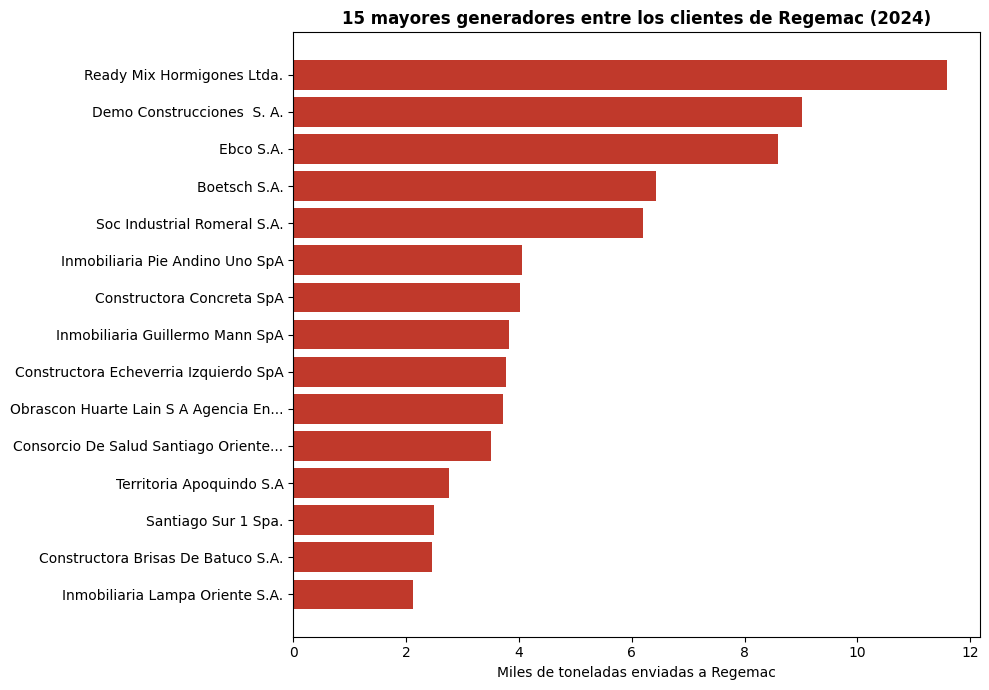

,toneladas
razon_social,
READY MIX HORMIGONES LIMITADA,11595.000
DEMO CONSTRUCCIONES S. A.,9020.000
EBCO S.A.,8592.020
BOETSCH S A,6426.000
SOC INDUSTRIAL ROMERAL S A,6198.128
INMOBILIARIA PIE ANDINO UNO SPA,4050.000
CONSTRUCTORA CONCRETA SPA,4018.860
INMOBILIARIA GUILLERMO MANN SPA,3830.000
CONSTRUCTORA ECHEVERRIA IZQUIERDO SPA,3771.000


In [12]:
clientes_regemac_anio = gi_rm[(gi_rm['anio'] == anio_gen) &
                               (gi_rm['trazabilidad_razon_social'].str.contains('REGENERADORA DE MATERIALES', na=False))]
gen_regemac = clientes_regemac_anio.groupby('razon_social')['toneladas'].sum().sort_values(ascending=False)

print(f"Generadores distintos que enviaron a Regemac en {anio_gen}: {gen_regemac.shape[0]}")
print(f"Toneladas totales: {gen_regemac.sum():,.0f} t")

top15_regemac = gen_regemac.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([nombre_corto_empresa(n) for n in top15_regemac.index][::-1], (top15_regemac.values / 1000)[::-1], color='#c0392b')
ax.set_xlabel('Miles de toneladas enviadas a Regemac')
ax.set_title(f'15 mayores generadores entre los clientes de Regemac ({anio_gen})', fontweight='bold')
plt.tight_layout()
plt.show()

top15_regemac


**¿Por qué no un gráfico de líneas de generadores año a año, como el de la sección 4?** Los destinatarios (Regemac, Cormi, etc.) son plantas fijas: existen todos los años y tiene sentido seguir su participación en el tiempo. Los generadores son obras/proyectos de construcción — la gran mayoría aparece uno o dos años y desaparece cuando la obra termina, no porque haya dejado el mercado. Una línea de tiempo por generador individual mezclaría "este generador perdió participación" con "esta obra específica terminó", que son cosas distintas. Por eso aquí se dejan como fotografías de un año (2024) en vez de una serie temporal — si más adelante quieres ver la *concentración* de generadores en el tiempo (no de un generador en particular, sino cuántos generadores explican el 80% del volumen cada año), eso sí es reproducible con lo que ya está cargado; avísame y lo agrego.

## 13. Limitaciones y qué falta

Siguiendo la misma disciplina que la auditoría de Pedro: esta sección distingue **actividad registrada** (lo que esta base sí calcula) de **formalización** (lo que no calcula sin un catastro externo).

- Lo que este cuaderno sí calcula: toneladas y participaciones dentro del filtro RETC (DF y GI, RM, LER 17), por año y por empresa; concentración de mercado (HHI); composición por material y tratamiento; cruce generador-destinatario.
- Lo que NO calcula: formalización de actores, cumplimiento de declaración, ni formalización de flujos (toneladas formales / generación física total) — para eso hace falta un catastro independiente y un denominador de generación física que no viene del RETC.
- Un RUT nuevo en el registro un año dado no prueba que entró recién al mercado formal: puede llevar años operando y solo haber cambiado de forma de declarar.
- Falta reincorporar la estimación de volumen desde los reportes de envío internos de Regemac (contenedores de 9-10 m³ propios vs. camiones externos) y el mapa geográfico con la fosa — dependen del archivo de envíos que no está cargado en esta sesión.
- Falta el Enfoque B (Permisos × WGR, proyección de generación física residencial 2027-2031) que Pedro dejó como pendiente de validación — no se reestima aquí.
